# Zero-difficulty attack success probability

Estimates the maximum success probability of the zero-difficulty attack against a Bitcoin NIPoPoW over time, together with the proof level transitions that drive it.

- A proof has level $\ell$ once at least $2K$ blocks of level $\ell$ exist, where a block $b$ has level $\mu$ when $h(b) \le T_b / 2^{\mu}$.
- The maximum success probability of the attack at proof level $\mu$ is $p(\mu) = (1 - 2^{-\mu})^{2m + k}$: Theorem 1 at $\Delta = 0$, i.e. the observation-phase bound of Lemma 4, with the hyperactivity-phase factor $1 - e^{-\Omega(K)}$ treated as exactly $1$, as in Table 1 of the paper. The exponent is $2m + k = \chi + k = 4032 + 323 = 4355$ (the paper writes $\chi$ as $2m$, with $m = 2016$ the epoch length).
- Observed level transitions are recomputed from `headers/headers.json`; future transitions are estimated from the expected $2K \cdot 2^{\ell}$ blocks at 10 minutes per block.
- Two date conventions coexist: x-tick dates beyond the last header extrapolate at 10 min/block from the last observed block (avoids a seam in the tick labels), while expected transition dates are anchored at genesis. The gap between them is real, as Bitcoin has averaged slightly under 10 minutes per block.

Figures: `attack-success-probability-over-time.pdf` and `proof-level-time-expected-vs-actual.pdf`.


In [1]:
import json
import math
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_style("whitegrid")

# Set matplotlib parameters globally
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 40,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 20,
    "axes.grid": True,
})

custom_palette = sns.color_palette("deep")
sns.set_palette(custom_palette)

In [2]:
# Load block headers (hash, bits, time), one record per height.
headers_file = "../headers/headers.json"
if not os.path.exists(headers_file):
    raise FileNotFoundError(
        f"{headers_file} not found. Extract headers/headers.zip, or regenerate "
        "it with src/export_all_headers.py.")
with open(headers_file) as f:
    df = pd.DataFrame(json.load(f))
df["height"] = df.index
df["timestamp_dt"] = pd.to_datetime(df["time"], unit="s")
df

,hash,bits,time,height,timestamp_dt
0,000000000019d6689c085ae165831e934ff763ae46a2a6...,1d00ffff,1231006505,0,2009-01-03 18:15:05
1,00000000839a8e6886ab5951d76f411475428afc90947e...,1d00ffff,1231469665,1,2009-01-09 02:54:25
2,000000006a625f06636b8bb6ac7b960a8d03705d1ace08...,1d00ffff,1231469744,2,2009-01-09 02:55:44
3,0000000082b5015589a3fdf2d4baff403e6f0be035a5d9...,1d00ffff,1231470173,3,2009-01-09 03:02:53
4,000000004ebadb55ee9096c9a2f8880e09da59c0d68b1c...,1d00ffff,1231470988,4,2009-01-09 03:16:28
...,...,...,...,...,...
865038,00000000000000000002af876a1d8ce11e1c07018b016a...,17030ecd,1728572242,865038,2024-10-10 14:57:22
865039,00000000000000000000445bb08413ba56b56068395864...,17030ecd,1728572873,865039,2024-10-10 15:07:53
865040,000000000000000000019ca8e0127b00104b98ef7297e4...,17030ecd,1728573656,865040,2024-10-10 15:20:56
865041,0000000000000000000116551169c5d38e6b66b8fe27ab...,17030ecd,1728574093,865041,2024-10-10 15:28:13


In [3]:
# Mining in Logarithmic Space parameters, matching src/argparser.py and the paper.
K = 104            # Security parameter; a proof level requires 2*K blocks of that level.
CHI = 4032         # Uncompressed part length; chi = 2m with m = 2016 the epoch length.
SMALL_K = 323      # Common prefix parameter (unstable part length).
N = CHI + SMALL_K  # Exponent 2m + k of the attack success probability.

GENESIS_DATE = df["timestamp_dt"].iloc[0]  # 2009-01-03 18:15:05 (UTC).
BLOCK_TIME = pd.Timedelta(minutes=10)      # Bitcoin's target block interval.
LAST_HEIGHT = int(df["height"].iloc[-1])
LAST_DATE = df["timestamp_dt"].iloc[-1]


def bits_to_target(bits):
    """Converts a compact 'bits' field to the full mining target.

    Same computation as src/bitcoin.py.

    Args:
        bits: Compact target as a hex string (e.g. "1d00ffff").

    Returns:
        The target as an integer.
    """
    bits = int(bits, 16)
    exponent = (bits >> 24) & 0xFF
    mantissa = bits & 0xFFFFFF
    return mantissa << (8 * (exponent - 3))


def block_level(block_hash, target):
    """Computes the level of a block, i.e. how far its hash is below its target.

    Same computation as src/block.py: floor(-log2(hash / target)).

    Args:
        block_hash: Block hash as a hex string.
        target: Mining target as an integer.

    Returns:
        The block level as an integer.
    """
    return math.floor(-math.log2(int(block_hash, 16) / target))


targets = df["bits"].map({bits: bits_to_target(bits) for bits in df["bits"].unique()})
df["block_level"] = [block_level(h, t) for h, t in zip(df["hash"], targets)]
df.loc[0, "block_level"] = 256  # Genesis level is infinity by convention: 256 (src/mls.py).

In [4]:
def p_attack(mu, n=N):
    """Maximum success probability of the zero-difficulty attack, (1 - 2^-mu)^n.

    Theorem 1 at Delta = 0, i.e. the observation-phase bound of Lemma 4; the
    hyperactivity-phase factor (1 - e^-Omega(K)) is treated as exactly 1, as
    in Table 1 of the paper. Computed as exp(n * log1p(-2^-mu)) for numerical
    stability; p(0) is exactly 0, and values below float64 range (mu <= 5)
    underflow to 0.0, which is harmless on a linear axis.

    Args:
        mu: Proof level, scalar or array-like.
        n: Exponent 2m + k. Defaults to the parameters of this notebook.

    Returns:
        The probability as a numpy scalar or array.
    """
    mu = np.asarray(mu, dtype=float)
    with np.errstate(divide="ignore"):
        return np.exp(n * np.log1p(-np.power(2.0, -mu)))


def expected_height(level):
    """Expected height at which the proof reaches the given level.

    The proof reaches level l once 2*K blocks of level l exist, and a block
    has level l with probability 2^-l, hence 2*K * 2^l blocks in expectation.

    Args:
        level: Proof level.

    Returns:
        The expected block height as an integer.
    """
    return 2 * K * 2**level


def expected_date(level):
    """Expected date of the level transition, anchored at genesis at 10 min/block."""
    return GENESIS_DATE + BLOCK_TIME * expected_height(level)


def height_tick_label(height):
    """Formats an x-tick as 'height (YYYY-MM)'.

    Dates come from the headers up to the last observed block, then from a
    10 min/block extrapolation anchored at the last observed block.

    Args:
        height: Block height.

    Returns:
        The tick label as a string.
    """
    if height <= LAST_HEIGHT:
        date = df.loc[height, "timestamp_dt"]
    else:
        date = LAST_DATE + BLOCK_TIME * (height - LAST_HEIGHT)
    return f"{height} ({date.strftime('%Y-%m')})"

In [5]:
# Observed proof level transitions: level l is reached when the 2*K-th block
# of level >= l appears (block levels are cumulative).
records = []
for level in range(1, 20):
    counts = np.cumsum(df["block_level"].to_numpy() >= level)
    if counts[-1] < 2 * K:
        break
    height = int(np.searchsorted(counts, 2 * K))
    records.append({"proof_level": level, "actual_height": height,
                    "actual_date": df.loc[height, "timestamp_dt"]})
transitions = pd.DataFrame(records)

LAST_LEVEL = int(transitions["proof_level"].iloc[-1])
NEXT_LEVEL = LAST_LEVEL + 1

# Check the probability formula against Table 1 of the paper (chi + k = 4355).
table_1 = {8: 0.000000039576, 9: 0.000200604207, 10: 0.014192981938,
           11: 0.119196227986, 12: 0.345292901557}
for mu, reference in table_1.items():
    assert abs(float(p_attack(mu, n=4355)) - reference) < 1e-9
assert float(p_attack(0)) == 0.0
assert transitions["actual_height"].is_monotonic_increasing
assert LAST_LEVEL == 12  # Matches the proof_level column of previous data dumps.

# Compare observed transitions with the expected model.
table = pd.concat([transitions, pd.DataFrame([{"proof_level": NEXT_LEVEL}])],
                  ignore_index=True)
table["expected_height"] = table["proof_level"].map(expected_height)
table["expected_date"] = table["proof_level"].map(expected_date)
table["delta_blocks"] = table["actual_height"] - table["expected_height"]
table["delta_days"] = (table["actual_date"] - table["expected_date"]).dt.days

# The height of the 2*K-th level-l block has relative deviation 1/sqrt(2*K),
# about 7%, at every level: each observed transition should be within ~4
# standard deviations of its expectation.
ratios = transitions["actual_height"] / transitions["proof_level"].map(expected_height)
assert ratios.between(0.7, 1.3).all()
table

,proof_level,actual_height,actual_date,expected_height,expected_date,delta_blocks,delta_days
0,1,437.0,2009-01-14 10:01:40,416,2009-01-06 15:35:05,21.0,7.0
1,2,897.0,2009-01-18 10:11:13,832,2009-01-09 12:55:05,65.0,8.0
2,3,1659.0,2009-01-24 22:41:45,1664,2009-01-15 07:35:05,-5.0,9.0
3,4,3330.0,2009-02-07 06:16:48,3328,2009-01-26 20:55:05,2.0,11.0
4,5,6534.0,2009-03-06 15:37:08,6656,2009-02-18 23:35:05,-122.0,15.0
5,6,12870.0,2009-05-01 08:38:05,13312,2009-04-06 04:55:05,-442.0,25.0
6,7,25915.0,2009-10-26 13:38:39,26624,2009-07-07 15:35:05,-709.0,110.0
7,8,52722.0,2010-04-23 21:59:59,53248,2010-01-08 12:55:05,-526.0,105.0
8,9,99719.0,2010-12-27 20:37:48,106496,2011-01-13 07:35:05,-6777.0,-17.0
9,10,205861.0,2012-10-31 14:32:59,212992,2013-01-21 20:55:05,-7131.0,-83.0


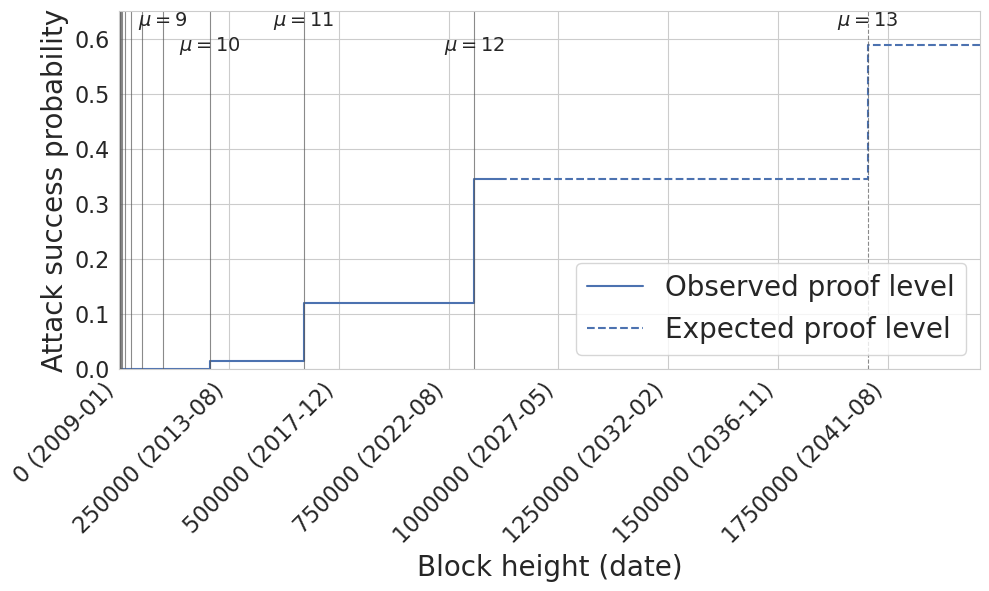

In [6]:
# Attack success probability over time: observed step from the transitions,
# then the expected continuation through the level-13 transition.
H_NEXT = expected_height(NEXT_LEVEL)
X_MAX = int(1.15 * H_NEXT)

fig, ax = plt.subplots()

# Observed part: proof level 0 from genesis, then each observed transition.
x_observed = np.concatenate([[0], transitions["actual_height"], [LAST_HEIGHT]])
y_observed = p_attack(np.concatenate([[0], transitions["proof_level"], [LAST_LEVEL]]))
ax.step(x_observed, y_observed, where="post", label="Observed proof level")

# Expected part: the level stays at 12 until the expected level-13 transition.
ax.step([LAST_HEIGHT, H_NEXT, X_MAX], p_attack([LAST_LEVEL, NEXT_LEVEL, NEXT_LEVEL]),
        where="post", color="C0", linestyle="--", label="Expected proof level")

# Mark the level transitions; annotate only the levels legible at this scale.
for _, row in transitions.iterrows():
    ax.axvline(row["actual_height"], color="0.35", linewidth=0.8, alpha=0.7)
ax.axvline(H_NEXT, color="0.35", linewidth=0.8, alpha=0.7, linestyle="--")
annotated = [(int(row["proof_level"]), row["actual_height"])
             for _, row in transitions.iterrows() if row["proof_level"] >= 9]
annotated.append((NEXT_LEVEL, H_NEXT))
for level, height in annotated:
    ax.text(height, 0.96 if level % 2 else 0.89, rf"$\mu = {level}$",
            transform=ax.get_xaxis_transform(), ha="center", fontsize=14)

xticks = np.arange(0, X_MAX + 1, 250_000)
ax.set_xticks(xticks)
ax.set_xticklabels([height_tick_label(h) for h in xticks], rotation=45, ha="right")
ax.set_xlim(0, X_MAX)
ax.set_ylim(0, 0.65)
ax.set_xlabel("Block height (date)", size=20)
ax.set_ylabel("Attack success probability", size=20)
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("attack-success-probability-over-time.pdf", format="pdf")
plt.show()

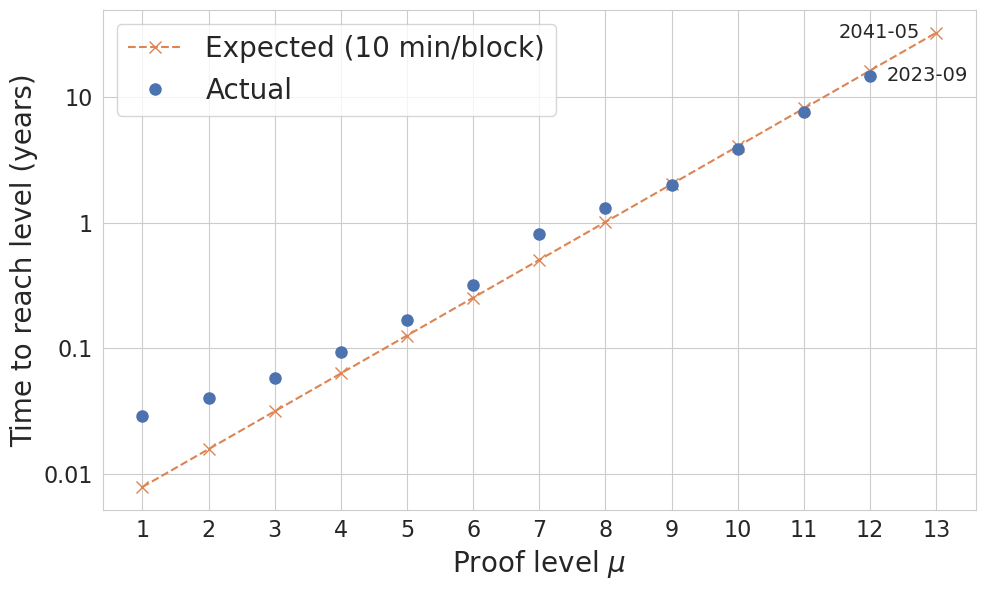

In [7]:
# Expected vs actual time to reach each proof level. The expected time doubles
# per level, i.e. a straight line on a log axis.
levels = np.arange(1, NEXT_LEVEL + 1)
expected_years = np.array([(expected_date(level) - GENESIS_DATE).total_seconds()
                           for level in levels]) / (365.25 * 86400)
actual_years = ((transitions["actual_date"] - GENESIS_DATE).dt.total_seconds()
                / (365.25 * 86400))

fig, ax = plt.subplots()
ax.plot(levels, expected_years, linestyle="--", marker="x", markersize=8,
        color="C1", label="Expected (10 min/block)")
ax.plot(transitions["proof_level"], actual_years, linestyle="none", marker="o",
        markersize=8, color="C0", label="Actual")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%g"))
ax.set_xticks(levels)
ax.set_xlabel(r"Proof level $\mu$", size=20)
ax.set_ylabel("Time to reach level (years)", size=20)

# Calendar dates for the two points that matter.
ax.annotate(expected_date(NEXT_LEVEL).strftime("%Y-%m"),
            (NEXT_LEVEL, expected_years[-1]),
            xytext=(-12, -4), textcoords="offset points", ha="right", fontsize=14)
ax.annotate(transitions["actual_date"].iloc[-1].strftime("%Y-%m"),
            (LAST_LEVEL, actual_years.iloc[-1]),
            xytext=(12, -4), textcoords="offset points", fontsize=14)
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig("proof-level-time-expected-vs-actual.pdf", format="pdf")
plt.show()